# 🏠 HOUSE PRICE PREDICTION MODEL


# Import Libraries


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


import warnings
warnings.filterwarnings("ignore")

# 1. LOAD DATASET


In [3]:
df = pd.read_csv("Housing.csv")
# Show basic info
print("Dataset Shape:", df.shape)
print(df.head())



Dataset Shape: (545, 13)
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


# 2. SPLIT FEATURES


In [4]:
X = df.drop("price", axis=1)
y = df["price"]


# Identify column types


In [6]:
numeric_features = ["area", "bedrooms", "bathrooms", "stories", "parking"]

categorical_features = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea",
    "furnishingstatus"
]


 # PREPROCESSING PIPELINE

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(drop="first")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# MODEL PIPELINE

In [12]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])


#  TRAIN TEST SPLIT

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


 # TRAIN MODEL

In [14]:
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['area', 'bedrooms',
                                                   'bathrooms', 'stories',
                                                   'parking']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['mainroad', 'guestroom',
                                                   'basement',
                                                   'hotwaterheating',
                                                   'airconditioning',
                                                   'prefarea',
                                                   'furnishingstatus'])])),
                ('regressor', LinearRegression())])

#  PREDICTION


In [16]:
y_pred = model.predict(X_test)


# EVALUATION

In [17]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n📊 MODEL PERFORMANCE")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


📊 MODEL PERFORMANCE
MAE : 970043.4039201641
MSE : 1754318687330.6675
RMSE: 1324506.96009144
R2 Score: 0.6529242642153177


# VISUALIZATION

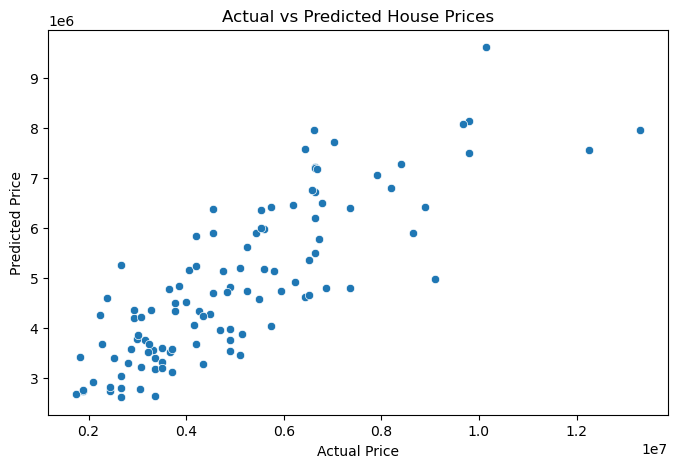

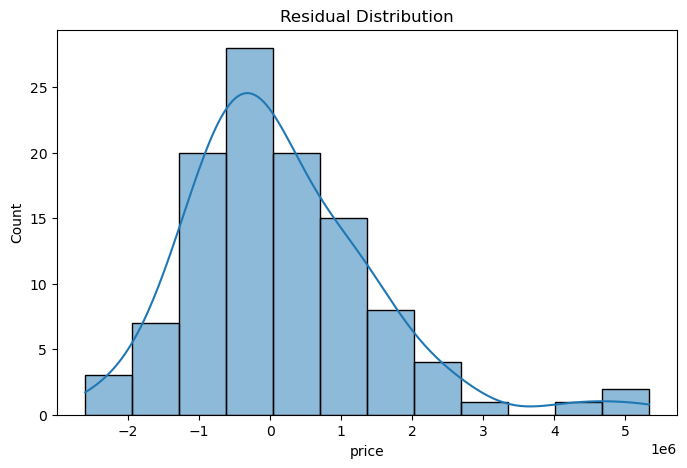

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

# Residuals
plt.figure(figsize=(8,5))
sns.histplot(y_test - y_pred, kde=True)
plt.title("Residual Distribution")
plt.show()

# SAVE MODEL

In [19]:
import joblib

joblib.dump(model, "house_price_model.pkl")

print("\n✅ Model Saved Successfully!")


✅ Model Saved Successfully!
